In [1]:
import pandas as pd

In [2]:
data=pd.read_csv('insurance.csv')

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
data.drop_duplicates(inplace=True)


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data['sex']=data['sex'].map({'male':1,'female':0})
data['smoker']=data['smoker'].map({'yes':1,'no':0})

In [8]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [9]:
data=pd.get_dummies(data,columns=['region'],drop_first=True,dtype=int)

In [10]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [12]:
X=data.drop('charges',axis=1)
y=data['charges']

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

In [16]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [25]:
model=Sequential()
model.add(Dense(units=32,activation='relu',input_dim=X_train.shape[1]))
model.add(Dense(units=16,activation='relu'))
model.add(Dense(units=1))
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.20)

Epoch 1/500


C:\Users\ahmed\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 308014400.0000 - mae: 13181.2959 - val_loss: 296417248.0000 - val_mae: 12448.8877
Epoch 2/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 307993888.0000 - mae: 13180.5908 - val_loss: 296397216.0000 - val_mae: 12448.1562
Epoch 3/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 307969632.0000 - mae: 13179.7383 - val_loss: 296369280.0000 - val_mae: 12447.1406
Epoch 4/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 307932448.0000 - mae: 13178.4492 - val_loss: 296323616.0000 - val_mae: 12445.5430
Epoch 5/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 307870880.0000 - mae: 13176.4609 - val_loss: 296252960.0000 - val_mae: 12443.1670
Epoch 6/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 307779328.0000 - mae: 13173.5146 - val_loss: 296147584.0000 - val_mae: 12439.7510
Epoch 7/500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 307645792.0000 - mae: 13169.3955 - val_loss: 296002144.0000 - val_mae: 12435.1279
Epoch 8/500
24/24 ━━━━━━

In [28]:
y_predict =model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [31]:
from sklearn.metrics import r2_score,mean_squared_error
r2_score(y_test,y_predict)


0.8035193227945434

In [32]:
mean_squared_error(y_test,y_predict)

33621323.17517897

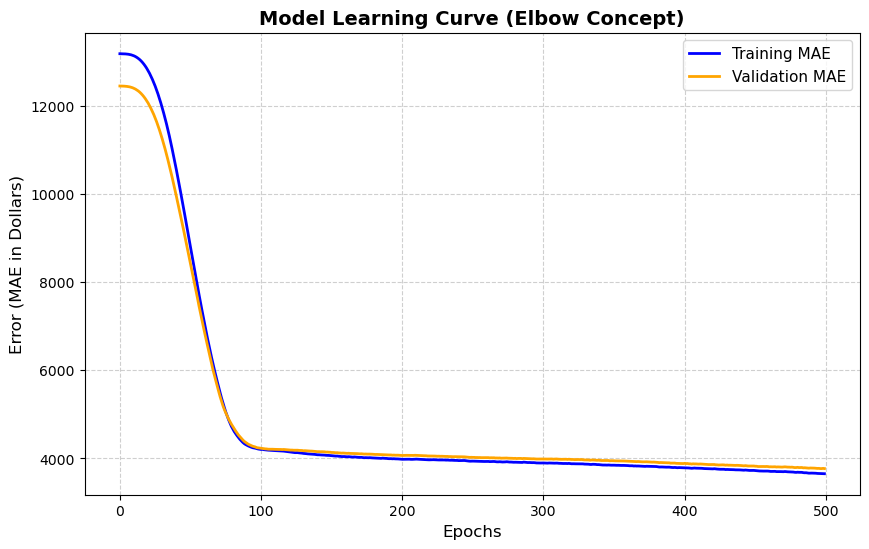

In [33]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


plt.plot(history.history['mae'], label='Training MAE', color='blue', linewidth=2)
if 'val_mae' in history.history:
    plt.plot(history.history['val_mae'], label='Validation MAE', color='orange', linewidth=2)


plt.title('Model Learning Curve (Elbow Concept)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Error (MAE in Dollars)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

